# Parallel workflow


In [44]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [45]:
class BatsmanState(TypedDict , total = False):
    runs    :   int
    balls   :   int
    six     :   int
    four    :   int
    sr      :   float
    bp      :   float
    bpb     :   float
    summary :   str

In [46]:
def sr(state: BatsmanState) -> dict:
    # Strike rate: handling division by zero if balls == 0
    sr_val = (state['runs'] / state['balls']) * 100 if state['balls'] > 0 else 0.0
    return {"sr": sr_val}

In [47]:
def bp(state: BatsmanState) -> dict:
    # Boundary runs percentage: handling division by zero if runs == 0
    bp_val = (((state['four'] * 4) + (state['six'] * 6)) / state['runs']) * 100 if state['runs'] > 0 else 0.0
    return {"bp": bp_val}

In [48]:
def bpb(state: BatsmanState) -> dict:
    # Balls per boundary: handling division by zero if no boundaries hit
    total_boundaries = state['four'] + state['six']
    bpb_val = state['balls'] / total_boundaries if total_boundaries > 0 else float('inf')
    return {"bpb": bpb_val}

In [49]:
def summary(state: BatsmanState) -> dict:
    # Format the final text
    summary_text = f"""
    Runs: {state['runs']},
    Balls: {state['balls']},
    Fours: {state['four']},
    Sixes: {state['six']},
    Strike Rate: {state.get('sr', 0):.2f},
    Boundary Percentage: {state.get('bp', 0):.2f}%
    Balls per Boundary: {state.get('bpb', 0):.2f}
    """
    return {"summary": summary_text.strip()}

In [50]:
graph = StateGraph(BatsmanState)

# Add nodes 
graph.add_node("SR", sr)
graph.add_node("BP", bp)
graph.add_node("BPB", bpb)
graph.add_node("Summary", summary)

# Add edges (Fan-out from START)
graph.add_edge(START, "SR")
graph.add_edge(START, "BP")
graph.add_edge(START, "BPB")

# Add edges (Fan-in to Summary)
graph.add_edge("SR", "Summary")
graph.add_edge("BP", "Summary")
graph.add_edge("BPB", "Summary")

# End workflow
graph.add_edge("Summary", END)

# Compile 
workflow_pg = graph.compile()

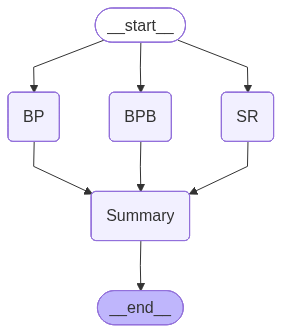

In [51]:
workflow_pg

In [52]:
if __name__ == "__main__":
    input_state = {
        "runs": 120,
        "balls": 80,
        "four": 10,
        "six": 5
    }

    final_state = workflow_pg.invoke(input_state)

    print("----- Final Summary Generated By LangGraph -----")
    print(final_state['summary'])

----- Final Summary Generated By LangGraph -----
Runs: 120,
    Balls: 80,
    Fours: 10,
    Sixes: 5,
    Strike Rate: 150.00,
    Boundary Percentage: 58.33%
    Balls per Boundary: 5.33
